<p align="center">
  <img src="Uniminuto.jpg" width="800"/>
</p>

# INVESTIGACIÓN SOBRE COMUNICACIÓN Y LIDERAZGO ÉTICO EN LAS JUNTAS DE ACCIÓN COMUNAL (JAL)

**Autores:**

- Cristian Camilo Cabrera Zambrano
- Yuddy Carolina Garzon Uribe
- Paulo Cesar Grimaldo Pérez
- Miguel Angel Orduz Largo
- Cristian Camilo Tangarife Morales


El presente cuaderno de código contiene el análisis cualitativo y cuantitativo sobre una investigación sobre la ética y la comunicación dentro del liderazgo en las Juntas de Acción Comunal de Bogotá. Varios líderes fueron entrevistados y encuestados para llevar a cabo la presente investigación, cuyo componente de análisis de datos ejecuta modelado de lenguaje natural y análisis estadístico exploratorio (EDA) para la interpretación científica de los resultados. Se señala que, a pesar de que este cuaderno contiene los modelos y resultados, su análisis se encuentra en el documento de investigación. 

**Objetivo general**
Analizar la relación entre el liderazgo ético ejercido por los directivos y la efectividad de la comunicación directiva en las Juntas de Acción Comunal que ejecutan Obras con Saldo Pedagógico del IDPAC en Bogotá durante el periodo 2024-2025.

**Objetivos específicos**

1)	Medir el nivel de liderazgo ético percibido por los equipos utilizando una adaptación del Ethical Leadership Questionnaire (ELQ). 
2)	Evaluar la efectividad de la comunicación directiva mediante una escala validada. 
3)	Proponer lineamientos para fortalecer competencias directivas en contextos de gestión de proyectos.


## Librerías

In [68]:
# 1. Manipulación y limpieza de datos
import pandas as pd # Para el manejo de datos tabulares (DataFrames)
import re # Expresiones regulares para limpiar puntuación y extraer palabras


# 2. Matemáticas y conteo
from collections import Counter # Para contar frecuencias de palabras
from itertools import combinations # Para crear pares de palabras en el grafo de red
import numpy as np
import scipy.stats as stats

# 3. Machine Learning y NLP (Procesamiento de Lenguaje Natural)
from sklearn.feature_extraction.text import TfidfVectorizer # Convierte texto a matriz matemática
from sklearn.decomposition import NMF # Algoritmo de Modelado de Tópicos (Factorización de Matrices)

# 4. Visualización de Datos
import plotly.graph_objects as go # Para gráficos interactivos y personalizados (Lollipop)
import plotly.express as px # Para mapas de calor y gráficos rápidos
import networkx as nx # Para crear la estructura matemática del grafo de red
import matplotlib.pyplot as plt # Para renderizar y guardar el grafo de red como imagen
import seaborn as sns
import os
import textwrap


## Configuración Global

Se define el listado de palabras comunes utilizadas para la expresión, que no son útiles para el análisis.

In [46]:
stop_words = set([
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'se', 'del', 'las', 'un', 'por', 'con', 'no', 'una', 
    'su', 'para', 'es', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 
    'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 
    'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 
    'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 
    'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 
    'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 'os',
    # Muletillas y ruido semántico identificado cualitativamente
    'pues', 'entonces', 'creo', 'hacer', 'tener', 'cómo', 'cosas', 'bueno', 'siempre', 'cada', 'digamos', 
    'tema', 'muchas', 'todas', 'primero', 'llegar', 'bajo', 'frente', 'tipo', 'parte', 'haciendo', 
    'hacemos', 'veces', 'ejemplo', 'caso', 'manera', 'forma', 'poder', 'está', 'tenemos', 'estamos', 
    'tuvimos', 'teníamos', 'estaba', 'alguien', 'hacia', 'cabo', 'cancha', 'acción', 'pienso', 'vamos', 'siendo'
])

## Recursos de datos

La base de datos de entrevistados, alojada en la variable **df**, contiene el consolidado de las entrevistas semiestructuradas. Las respuestas giran alrededor del banco de preguntas. Sobre esta se realizarán análisis cuantitativos, categóricos y discursivos.

La base de datos de encuestas, alojada en la variable **df2** contiene las respuestas del formulario de encuestas. Será utilizada para el EDA y la visualización para el análisis.

In [4]:
df = pd.read_excel(r"C:\Users\qluis\Downloads\entrevistas.xlsx")
df.head()

,ENCUESTADO,ENCUESTADOR,DESCRIBA BREVEMENTE EL PROYECTO Y SU ROL,¿CUÁLES SON LOS PRINCIPALES DESAFÍOS DE LIDERAR EQUIPOS DE PROYECTOS EN SU ORGANIZACIÓN?,¿QUÉ SIGNIFICA PARA USTED EJERCER UN LIDERAZGO ÉTICO EN LA GESTIÓN DE PROYECTOS?,¿CUÁLES SON LOS PRINCIPIOS O VALORES QUE ORIENTAN SU DECISIÓN COMO LÍDER?,RELATE UNA SITUACIÓN DONDE LA ÉTICA HAYA SIDO DETERMINANTE EN UNA DECISIÓN DEL PROYECTO,¿CÓMO MANEJAS LOS DILEMAS ENTRE RESULTADOS Y PRINCIPIOS ÉTICOS?,¿CÓMO DESCRIBE SU ESTILO DE COMUNICACIÓN CON EL EQUIPO?,¿QUÉ ESTRATEGIAS USA PARA ASEGURAR CLARIDAD EN LA COMUNICACIÓN?,¿CÓMO GESTIONA LA RETROALIMENTACIÓN?,¿CÓMO CREE QUE INFLUYE LA COMUNICACIÓN EN LA CONFIANZA DEL EQUIPO?,¿QUÉ APRENDIZAJES HA OBTENIDO COMO LÍDER DE PROYECTOS?,¿QUÉ RECOMENDACIONES DARÍA PARA FORTALECER LIDERAZGO ÉTICO Y COMUNICACIÓN?,¿DESEA AGREGAR ALGO MÁS A LA ENTREVISTA?,CÓMO SE RELACIONAN ÉTICA Y COMUNICACIÓN EN SU EXPERIENCIA?
0,E1,CAMILO CABRERA,nosotros presentamos una propuesta en la cual ...,Los desafíos es mucha muchas veces que la gent...,Principalmente es actuar con transparencia tan...,"Tener compromiso con el proyecto, con el objet...",pues se me presentó como decían los puntos ant...,Que es como lo que le decía de las cámaras de ...,Pues considero que tengo una buena comunicació...,Nosotros realizamos en reuniones en dependiend...,"Pues es un siempre me gusta, obviamente, escuc...","No, eso pues es vital, pues digamos, acá hay m...","Uy, la verdad, arquitecto muchos porque pues c...","Pues bueno, acá nosotros, pues hablar, tener l...","No, pues en el Pues sí, me gustaría decir que ...",NaN
1,E2,YUDDY GARZÓN,"Bueno, actualmente estamos ejecutando unos sen...",Mira yo creería que fundamentalmente son los t...,"Pues tomar buenas decisiones, no quedarnos con...","Bueno, antes que nada, el respeto, el respeto ...","Bueno, pues no tengo así ahorita uno exacto, p...","Todo lo que es hablar, pues hablar como nosotr...","Bueno, nuestra comunicación me parece que tene...","Bueno, creo que nuestra comunicación principal...","Bueno, pues cuando hay algún tipo de retroalim...",Tú no te puedes comunicar con una persona en l...,El primer aprendizaje que he tenido es partici...,"Yo creo que la, o sea, lo fundamental es la co...",Que sería chévere que realizaran de pronto más...,la ética yo yo relacionaría todos sabes la éti...
2,E3,MIGUEL ORDUZ,"Listo, entonces el rol de nosotros, nosotros h...",Los problemas que nosotros tuvimos es llegar a...,"Para mí ético, tener ser transparente en todo ...","Los principios, la transparencia, la responsab...",la transparencia lo que yo te estaba diciendo ...,Con el diálogo.\nNosotros debemos hablar con e...,"De una manera sentir.\nDe una manera asertiva,...","Bueno, pues en este caso lo que yo hago es bus...",¿Cómo es que no yo la retroalimentación que me...,La confianza realmente mostrando resultados. E...,"De aprendizajes, tengo el aprendizaje de que p...","No, pues yo creo que tener pues la disposición...",NaN,En mi experiencia con los procesos que he real...
3,E4,PAULO GRIMALDO,Como presidente de la Junta de Acción Comunal....,Poder establecer y llegar a acuerdos con difer...,Un reto de día a día de levantarme de saber qu...,"Primero, el respeto.\nCreo mucho en la horizo...",Estos proyectos comunitarios por no tener.\nUn...,"Desde la cocreación establezco algo cumplible,...","De una manera cordial, creo mucho en que más a...","Nosotros, por la población que tenemos, establ...","Bueno, va muy de la mano con lo que les explic...","Más que la comunicación, es el cumplimiento y ...","¿En que cada, en que cada día?\nHay un evento ...","Hablar con la verdad, creo que informar a mi e...","Sí, que importante que ustedes.\nEstán estudia...","La ética y la comunicación. Bueno, yo creo que..."
4,E5,CRISTIAN TANGARIFE,"Bueno, pues el proyecto, pues aquí como junta ...","Bueno, pues acá como junta, pues yo creo que l...","Bueno, pues como líder y representante acá de ...","Siempre la honestidad, la honestidad y la tran...","Bueno

In [57]:
df2 = pd.read_excel(r"C:\Users\qluis\Downloads\Investigacion\RESULTADO ENCUESTAS\_Liderazgo Ético 2026 Juntas de Acción Comunal ejecutoras de Obras con Saldo Pedagógico del IDPAC (respuestas) (5).xlsx")
df2.head()

,Marca temporal,Puntuación,Tipo de organización,Rol en el proyecto,Tiempo de participación en el proyecto,Número aproximado de personas en el equipo,1. Mi líder actúa de manera consistente con los valores que promueve.,"2. Mi líder cumple lo que promete, incluso en situaciones difíciles.",3. Mi líder toma decisiones que reflejan principios éticos claros.,4.Mi líder trata a todos los miembros del equipo con justicia.,...,16. Mi líder comunica la información a tiempo para poder actuar adecuadamente.,17. Mi líder mantiene al equipo informado sobre cambios relevantes del proyecto.,18. Mi líder ofrece retroalimentación constructiva sobre nuestro desempeño.,19. Mi líder escucha activamente las inquietudes del equipo.,20. Lo que mi líder comunica es coherente con sus acciones.,21. Las decisiones del líder se explican de manera comprensible.,22. Mi líder fomenta un ambiente donde se puede hablar con libertad.,23. Me siento cómodo(a) expresando mis ideas a mi líder.,24. Pregunta abierta:\nTipo: Respuesta larga\n¿Qué aspectos de la comunicación del líder considera que deberían mejorarse?,Columna 30
0,2026-02-25 18:00:02.522,0,Privada,Miembro del equipo,Más de 1 año,Entre 5 y 10,4 De acuerdo,4 De acuerdo,3 Ni de acuerdo ni en desacuerdo,4 De acuerdo,...,3 Ni de acuerdo ni en desacuerdo,4 De acuerdo,3 Ni de acuerdo ni en desacuerdo,4 De acuerdo,3 Ni de acuerdo ni en desacuerdo,3 Ni de acuerdo ni en desacuerdo,4 De acuerdo,4 De acuerdo,Transmitir la información con claridad y trans...,NaN
1,2026-02-25 18:25:32.872,0,Privada,Miembro del equipo,Más de 1 año,Menos de 5,3 Ni de acuerdo ni en desacuerdo,4 De acuerdo,3 Ni de acuerdo ni en desacuerdo,2 En desacuerdo,...,3 Ni de acuerdo ni en desacuerdo,3 Ni de acuerdo ni en desacuerdo,3 Ni de acuerdo ni en desacuerdo,5 Totalmente de acuerdo,4 De acuerdo,4 De acuerdo,4 De acuerdo,4 De acuerdo,Mi líder tiene una comunicación asertiva sin e...,NaN
2,2026-02-25 18:34:03.518,0,Privada,Miembro del equipo,Más de 1 año,Entre 5 y 10,3 Ni de acuerdo ni en desacuerdo,3 Ni de acuerdo ni en desacuerdo,3 Ni de acuerdo ni en desacuerdo,2 En desacuerdo,...,2 En desacuerdo,2 En desacuerdo,2 En desacuerdo,2 En desacuerdo,3 Ni de acuerdo ni en desacuerdo,2 En desacuerdo,3 Ni de acuerdo ni en desacuerdo,2 En desacuerdo,No se sabe comunicar y en muchas oportunidades...,NaN
3,2026-02-25 18:37:17.083,0,Privada,Miembro del equipo,Más de 1 año,Menos de 5,1 Totalmente en desacuerdo,1 Totalmente en desacuerdo,1 Totalmente en desacuerdo,1 Totalmente en desacuerdo,...,1 Totalmente en desacuerdo,1 Totalmente en desacuerdo,1 Totalmente en desacuerdo,1 Totalmente en desacuerdo,4 De acuerdo,4 De acuerdo,1 Totalmente en desacuerdo,4 De acuerdo,Siento que lo único que tiene por mejorar es q...,NaN
4,2026-02-25 18:43:49.290,0,Privada,Miembro del equipo,Entre 6 meses y 1 año,Más de 10,4 De acuerdo,3 Ni de acuerdo ni en desacuerdo,3 Ni de acuerdo ni en desacuerdo,3 Ni de acuerdo ni en desacuerdo,...,2 En desacuerdo,2 En desacuerdo,2 En desacuerdo,2 En desacuerdo,4 De acuerdo,4 De acuerdo,2 En desacuerdo,3 Ni de acuerdo ni en desacuerdo,Considero que sería mejor tener en cuenta la o...,NaN


## Análisis de entrevistas

### Modelado de tópicos (NMF)

In [47]:
columnas_preguntas = df.columns[2:]

documentos = []
nombres_encuestados = []

# 2. Agrupación por líder
for index, fila in df.iterrows():
    texto_encuestado = " ".join([str(fila[col]) for col in columnas_preguntas if str(fila[col]) != 'nan'])
    documentos.append(texto_encuestado)
    # Extraemos el nombre del líder para las etiquetas de los gráficos
    nombres_encuestados.append(fila['ENCUESTADO'] if 'ENCUESTADO' in df.columns else f"Líder {index+1}")

# 3. Función de limpieza y tokenización
def limpiar_y_tokenizar(texto):
    palabras = re.findall(r'\b[a-záéíóúñ]+\b', texto.lower())
    return [w for w in palabras if w not in stop_words and len(w)>3]

# Guardamos los tokens (listas de palabras) y el texto unido
documentos_tokenizados = [limpiar_y_tokenizar(doc) for doc in documentos]
documentos_limpios = [" ".join(tokens) for tokens in documentos_tokenizados]

# 4. Modelado NMF
vectorizador = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
tfidf = vectorizador.fit_transform(documentos_limpios)

nmf_model = NMF(n_components=3, random_state=42)
W = nmf_model.fit_transform(tfidf) # Matriz Documento-Tópico (Pesos por líder)
H = nmf_model.components_ # Matriz Tópico-Palabra (Pesos por palabra)
nombres_caracteristicas = vectorizador.get_feature_names_out()

# Ejes temáticos definidos académicamente
topicos_nombres = [
    'T1: Gestión y Procesos', 
    'T2: Decisiones y Transparencia', 
    'T3: Ejecución y Normas'
]
print("Modelo de tópicos ejecutado correctamente.")

Modelo de tópicos ejecutado correctamente.


### Visualizaciones

In [51]:
# Configuración para que el botón de cámara descargue en alta resolución (4K)
config_descarga = {
  'toImageButtonOptions': {
    'format': 'png', 
    'filename': 'grafico_exportado',
    'height': 600,
    'width': 1000,
    'scale': 3 # Escala 3 para resolución de documento académico
  }
}

# --- 1. LOLLIPOP CHART (Tema 1) ---
top_indices_1 = H[0].argsort()[:-10 - 1:-1]
top_palabras_1 = [nombres_caracteristicas[i] for i in top_indices_1][::-1] 
pesos_1 = [H[0][i] for i in top_indices_1][::-1]

fig_bar = go.Figure()
fig_bar.add_trace(go.Bar(x=pesos_1, y=top_palabras_1, orientation='h', width=0.05, marker_color='gray'))
fig_bar.add_trace(go.Scatter(x=pesos_1, y=top_palabras_1, mode='markers', marker=dict(color='darkblue', size=12)))

fig_bar.update_layout(
    title="Peso de Conceptos Clave (Tema 1)",
    plot_bgcolor='white', margin=dict(l=100, r=20, t=60, b=40)
)

print("Gráfico Lollipop. Pasa el ratón por encima y haz clic en la cámara (arriba a la derecha) para descargar:")
fig_bar.show(config=config_descarga)


# --- 2. HEATMAP (Concentración Temática) ---
fig_heat = px.imshow(W,
                labels=dict(x="Eje Temático", y="Participante", color="Intensidad"),
                x=topicos_nombres, y=nombres_encuestados,
                color_continuous_scale='Blues', aspect='auto')

#fig_heat.update_layout(title="Concentración del Discurso por Entrevistado", margin=dict(l=120, r=20, t=60, b=80))

print("Mapa de Calor. Pasa el ratón por encima y haz clic en la cámara (arriba a la derecha) para descargar:")
fig_heat.show(config=config_descarga)

Gráfico Lollipop. Pasa el ratón por encima y haz clic en la cámara (arriba a la derecha) para descargar:


Mapa de Calor. Pasa el ratón por encima y haz clic en la cámara (arriba a la derecha) para descargar:


In [50]:
# 1. Extraer los datos de la matriz H para los 3 tópicos
datos_todos_topicos = []
nombres_academicos = [
    'T1: Gestión y Procesos', 
    'T2: Decisiones y Transparencia', 
    'T3: Ejecución y Normas'
]

for idx_topico, topico in enumerate(H):
    top_indices = topico.argsort()[:-10 - 1:-1]
    for indice in top_indices:
        datos_todos_topicos.append({
            'Eje Temático': nombres_academicos[idx_topico],
            'Concepto Clave': nombres_caracteristicas[indice].capitalize(),
            'Peso NMF (Importancia)': topico[indice]
        })

df_todos_topicos = pd.DataFrame(datos_todos_topicos)
df_todos_topicos = df_todos_topicos.sort_values(by=['Eje Temático', 'Peso NMF (Importancia)'], ascending=[True, True])

# 2. Crear Gráfico Facetado
fig_all = px.bar(df_todos_topicos, x='Peso NMF (Importancia)', y='Concepto Clave', 
                 facet_col='Eje Temático', color='Eje Temático', orientation='h', 
                 color_discrete_sequence=['#2C3E50', '#005A9C', '#3498DB'])

# 3. CORRECCIÓN DE DISEÑO Y TEXTOS SUPERPUESTOS
fig_all.update_yaxes(matches=None, showticklabels=True)

# Esta línea limpia el "Eje Temático = " que Plotly pone por defecto y lo pone en negrita
fig_all.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[-1].strip()}</b>", font=dict(size=14)))

fig_all.update_layout(
    #title=dict(text="Composición Estructural de los Ejes Temáticos", font=dict(size=22), y=0.96),
    showlegend=False, 
    plot_bgcolor='white',
    height=550,
    margin=dict(t=110, b=40, l=80, r=40) # <- El margen superior (t=110) evita la superposición
)

# 4. Mostrar para descarga
config_descarga_topicos = {
  'toImageButtonOptions': {'format': 'png', 'filename': 'topicos_completos', 'height': 600, 'width': 1200, 'scale': 3}
}

print("Renderizado corregido. Haz clic en la cámara para descargar:")
fig_all.show(config=config_descarga_topicos)

Renderizado corregido. Haz clic en la cámara para descargar:


### Red de co-ocurrencia

In [54]:
# 1. Construir pares de palabras únicas por respuesta
pares_palabras = []
for tokens in documentos_tokenizados:
    pares = list(combinations(set(tokens), 2))
    pares_palabras.extend(pares)

# 2. Tomar los 40 pares más fuertes
conteo_pares = Counter(pares_palabras).most_common(40)

# 3. Construir el grafo
G = nx.Graph()
for par, peso in conteo_pares:
    G.add_edge(par[0], par[1], weight=peso)

# 4. Renderizar
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.8, iterations=50)
grados = dict(G.degree)

nx.draw_networkx_nodes(G, pos, node_size=[v * 100 for v in grados.values()], node_color='#87CEEB', alpha=0.8, edgecolors='white')
nx.draw_networkx_edges(G, pos, width=[d['weight']*0.5 for (u, v, d) in G.edges(data=True)], edge_color='gray', alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight='bold')

#plt.title("Red de Co-ocurrencia de Conceptos en Entrevistas", fontsize=16)
plt.axis('off')
plt.tight_layout()

# 5. Exportar a imagen local
plt.savefig('grafo_coocurrencia.png', dpi=300, bbox_inches='tight')
plt.close() # Cierra la figura en memoria
print("Grafo de red exportado como 'grafo_coocurrencia.png'.")

Grafo de red exportado como 'grafo_coocurrencia.png'.


### Análisis de sentimentalidad

In [ ]:
# 1. Léxico cualitativo ampliado y refinado
palabras_positivas = ['ética', 'transparencia', 'confianza', 'claridad', 'éxito', 'apoyo', 'solución', 'líder', 'mejora', 'acuerdo', 'comunicación', 'verdad', 'ganadores', 'logro', 'oportunidad', 'beneficio', 'avance', 'equipo']
palabras_negativas = ['dilema', 'problema', 'desafío', 'difícil', 'falta', 'error', 'conflicto', 'riesgo', 'retraso', 'queja', 'malo', 'peor', 'tensión', 'obstáculo', 'complicado', 'choque']

resultados_sentimiento = []

# 2. Evaluación algorítmica por líder
for index, fila in df.iterrows():
    lider = nombres_encuestados[index]
    puntaje_positivo = 0
    puntaje_negativo = 0
    
    for col in columnas_preguntas:
        respuesta = str(fila[col]).lower()
        if respuesta != 'nan':
            tokens = re.findall(r'\b[a-záéíóúñ]+\b', respuesta)
            puntaje_positivo += sum(1 for w in tokens if w in palabras_positivas)
            puntaje_negativo += sum(1 for w in tokens if w in palabras_negativas)
            
    total_palabras = puntaje_positivo + puntaje_negativo
    
    # Índice de Polaridad normalizado (-1 a 1)
    polaridad = (puntaje_positivo - puntaje_negativo) / total_palabras if total_palabras > 0 else 0
        
    resultados_sentimiento.append({
        'Participante': lider,
        'Positivas': puntaje_positivo,
        'Negativas': puntaje_negativo,
        'Índice de Polaridad': round(polaridad, 3)
    })

df_sentimiento = pd.DataFrame(resultados_sentimiento)

# 3. Visualización con esquema de colores divergente
fig_sent = px.bar(df_sentimiento, x='Participante', y='Índice de Polaridad', 
                  color='Índice de Polaridad', 
                  color_continuous_scale='RdBu', # Red to Blue (Negativo a Positivo)
                  color_continuous_midpoint=0)   # Fuerza el cero como el centro de color

fig_sent.update_layout(
    title="Análisis de Sentimiento (Polaridad del Discurso) por Entrevistado",
    yaxis_title="← Tendencia Negativa  |  Tendencia Positiva →",
    plot_bgcolor='white'
)
# Agregar línea neutral en el eje Y (cero)
fig_sent.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)

# 4. Mostrar con configuración de descarga manual en 4K
config_descarga_sent = {
  'toImageButtonOptions': {'format': 'png', 'filename': 'sentimiento_lideres', 'height': 600, 'width': 1000, 'scale': 3}
}

print("Análisis exitoso. Haz clic en la cámara para descargar:")
fig_sent.show(config=config_descarga_sent)

# Visualizar tabla resumen en el notebook
df_sentimiento

Hello World


## Análisis de la encuesta

### Análisis Estadístico Exploratorio

--- ANÁLISIS DE CORRELACIÓN ---
Coeficiente de Correlación de Pearson (r): 0.961
Valor p: 5.992e-60

[!] Existe una correlación estadísticamente significativa. Procediendo con regresión lineal simple...
Ecuación del modelo: Comunicación = 0.064 + (0.978 * Liderazgo Ético)
Coeficiente de Determinación (R²): 0.924


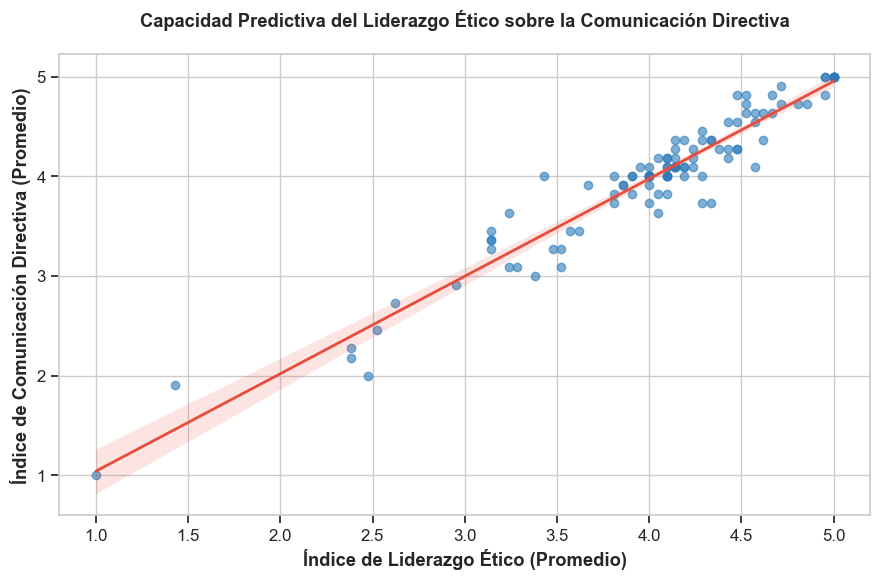

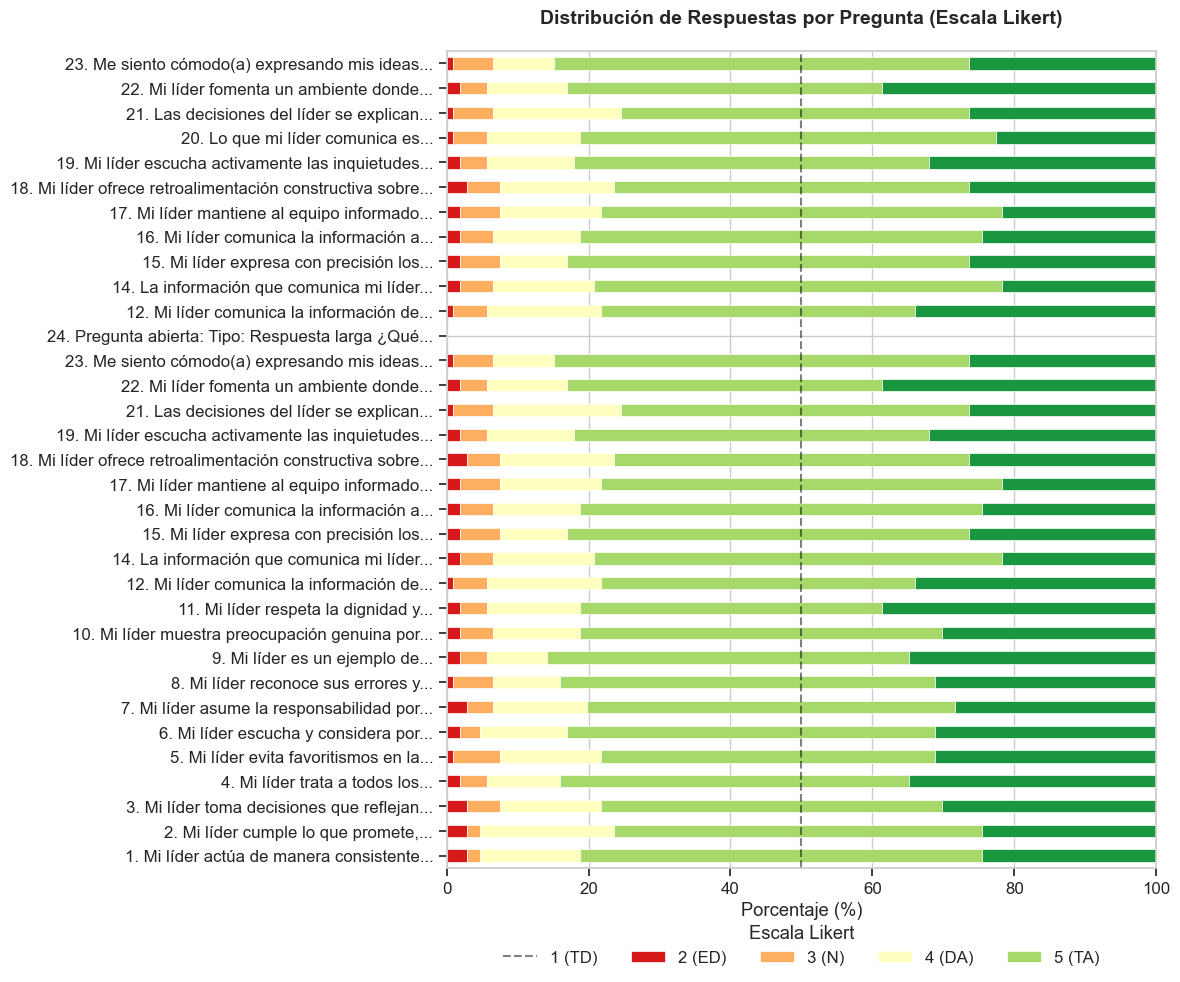


--- EJEMPLOS DE RESPUESTAS ABIERTAS ---

Pregunta: Pregunta abierta:
13. En su opinión, ¿qué comportamientos de su líder reflejan mayormente su ética personal?
 - En ocasiones ha beneficiado a personas cercanas a ella con el pago de servicios contratados.
 - En el momento que nos escucha con Directivos y toma alguna decisión aun él no este de acuerdo
 - Considero que su mayor comportamiento etico es cuando maneja recursos y siento que no se los roba
 - Nuestro líder es un ser humano maravilloso, tiene buena comunicación con todos, no es imponente, respeta nuestras opiniones y es muy respetuoso con todos.
 - No se qué tante ética pueda tener el líder, ya que somos tantos que a veces siento que ni nos escuchamos, pienso que su parte más ética es que no nos trata mal

Pregunta: 24. Pregunta abierta:
Tipo: Respuesta larga
¿Qué aspectos de la comunicación del líder considera que deberían mejorarse?
 - Transmitir la información con claridad y transparencia, adicional con un tiempo prudente 

In [ ]:
# 0. LIMPIEZA Y TRANSFORMACIÓN DE DATOS
# ==========================================
# Extrae solo el número inicial de las respuestas
def extraer_numero(texto):
    if pd.isna(texto):
        return np.nan
    texto_str = str(texto).strip()
    match = re.match(r'^(\d)', texto_str)
    if match:
        return float(match.group(1))
    return np.nan

# Definir variables de Liderazgo Ético (Preguntas 1 a 11)
cols_liderazgo = [col for col in df2.columns if any(str(i)+'.' in col[:3] for i in range(1, 12))]

# Definir variables de Comunicación Directiva (Preguntas 12, 14 a 23)
cols_comunicacion = [col for col in df2.columns if any(str(i)+'.' in col[:3] for i in [12] + list(range(14, 24)))]

todas_likert = cols_liderazgo + cols_comunicacion

# Crear una copia de trabajo para no afectar el df2 original por si acaso
df_clean = df2.copy()

# Aplicar la limpieza a todas las columnas Likert
for col in todas_likert:
    df_clean[col] = df_clean[col].apply(extraer_numero)

# Eliminar filas donde todas las respuestas Likert estén vacías
df_clean = df_clean.dropna(subset=todas_likert, how='all')

# ==========================================
# 1. PREPARACIÓN DE CONSTRUCTOS
# ==========================================
# Calcular índices compuestos (promedios) para cada dimensión
df_clean['Indice_Liderazgo'] = df_clean[cols_liderazgo].mean(axis=1)
df_clean['Indice_Comunicacion'] = df_clean[cols_comunicacion].mean(axis=1)

# Eliminar nulos en los índices para evitar errores en el cálculo de Pearson
df_corr = df_clean.dropna(subset=['Indice_Liderazgo', 'Indice_Comunicacion'])

# ==========================================
# 2. CORRELACIÓN DE PEARSON Y REGRESIÓN
# ==========================================
print("--- ANÁLISIS DE CORRELACIÓN ---")
corr, p_value = stats.pearsonr(df_corr['Indice_Liderazgo'], df_corr['Indice_Comunicacion'])

print(f"Coeficiente de Correlación de Pearson (r): {corr:.3f}")
print(f"Valor p: {p_value:.3e}")

if p_value < 0.05:
    print("\n[!] Existe una correlación estadísticamente significativa. Procediendo con regresión lineal simple...")
    
    slope, intercept, r_value, p_val_reg, std_err = stats.linregress(
        df_corr['Indice_Liderazgo'], 
        df_corr['Indice_Comunicacion']
    )
    
    print(f"Ecuación del modelo: Comunicación = {intercept:.3f} + ({slope:.3f} * Liderazgo Ético)")
    print(f"Coeficiente de Determinación (R²): {r_value**2:.3f}")
    
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("notebook", font_scale=1.1)

    plt.figure(figsize=(9, 6))
    sns.regplot(
        x='Indice_Liderazgo', y='Indice_Comunicacion', data=df_corr, 
        scatter_kws={'alpha':0.6, 'color':'#2b7bba'}, 
        line_kws={'color':'#e74c3c', 'linewidth': 2}
    )
    plt.title('Capacidad Predictiva del Liderazgo Ético sobre la Comunicación Directiva', pad=20, weight='bold')
    plt.xlabel('Índice de Liderazgo Ético (Promedio)', weight='bold')
    plt.ylabel('Índice de Comunicación Directiva (Promedio)', weight='bold')
    plt.tight_layout()
    plt.savefig("01_correlacion_liderazgo_comunicacion.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("\n[!] No se encontró correlación significativa (p > 0.05). Pasando a visualizaciones descriptivas.")

# ==========================================
# 3. ANÁLISIS DESCRIPTIVO DE PREGUNTAS LIKERT
# ==========================================
# Preparar paleta de colores para Likert (Rojo a Verde)
color_likert = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']

distribuciones = []
for col in todas_likert:
    conteo = df_clean[col].value_counts(normalize=True).sort_index()
    para_grafico = {1:0, 2:0, 3:0, 4:0, 5:0}
    for val, prop in conteo.items():
        if pd.notna(val) and val in para_grafico:
            para_grafico[val] = prop * 100
            
    partes = col.split('.')
    nombre_corto = partes[0] + ". " + ' '.join(partes[1].split()[:6]) + "..." if len(partes)>1 else col[:30]
    para_grafico['Pregunta'] = nombre_corto
    distribuciones.append(para_grafico)

df_dist = pd.DataFrame(distribuciones).set_index('Pregunta')

fig, ax = plt.subplots(figsize=(12, 10))
df_dist.plot(kind='barh', stacked=True, color=color_likert, ax=ax, edgecolor='white', linewidth=0.5)

plt.axvline(x=50, color='black', linestyle='--', alpha=0.5) 
plt.title('Distribución de Respuestas por Pregunta (Escala Likert)', pad=20, fontsize=14, weight='bold')
plt.xlabel('Porcentaje (%)')
plt.ylabel('')
plt.legend(title='Escala Likert', labels=['1 (TD)', '2 (ED)', '3 (N)', '4 (DA)', '5 (TA)'], 
           loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig("02_likerk.png", dpi=300, bbox_inches="tight")
plt.show()

# ==========================================
# 4. ANÁLISIS CUALITATIVO (PREGUNTAS ABIERTAS)
# ==========================================
print("\n--- EJEMPLOS DE RESPUESTAS ABIERTAS ---")
# Identificar las columnas de texto abierto
cols_abiertas = [col for col in df2.columns if '13.' in col or '24.' in col]

for col in cols_abiertas:
    print(f"\nPregunta: {col}")
    # Tomar las respuestas únicas, quitando nulos
    respuestas = df2[col].dropna().unique()
    for resp in respuestas[:5]:  # Muestra los primeros 5 comentarios a modo de ejemplo
        if isinstance(resp, str) and len(resp.strip()) > 5:
            print(f" - {resp.strip()}")

### Gráficos adicionales

[+] Exportado exitosamente: graficos_tesis/03_lollipop_fortalezas_debilidades


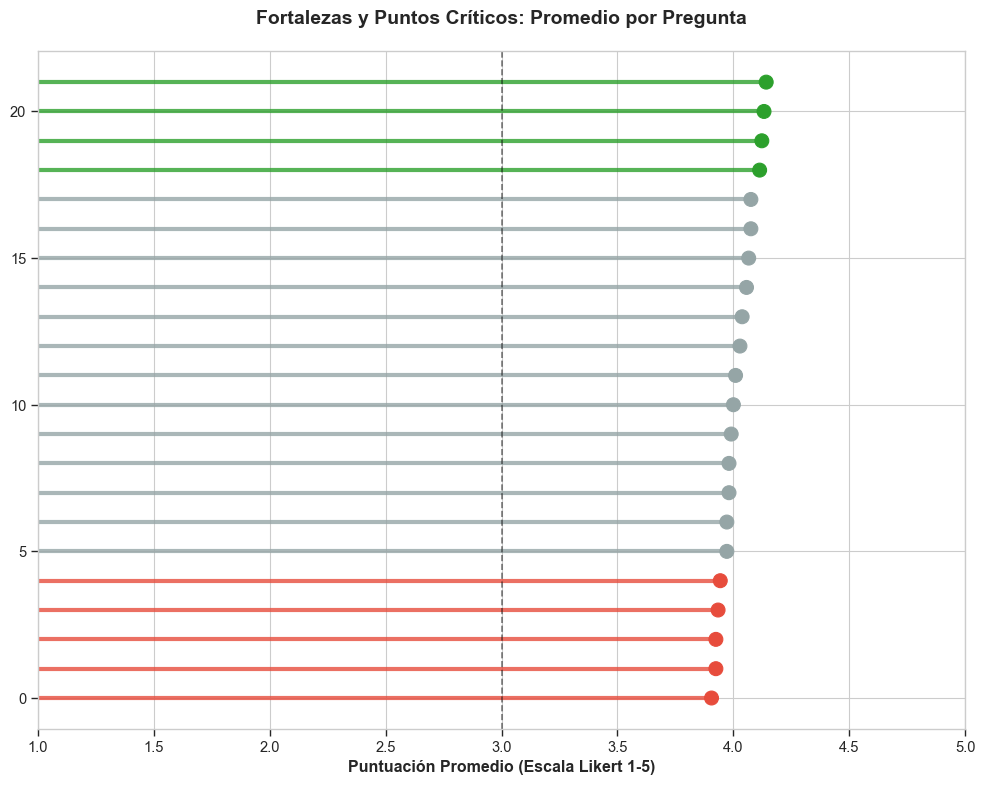


--- ANOVA: TIEMPO DE PARTICIPACIÓN ---
Valor p: 0.441


C:\Users\qluis\AppData\Local\Temp\ipykernel_18924\4060575945.py:71: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#2c3e50'` for the same effect.




[+] Exportado exitosamente: graficos_tesis/04_violin_anova_tiempo_comunicacion


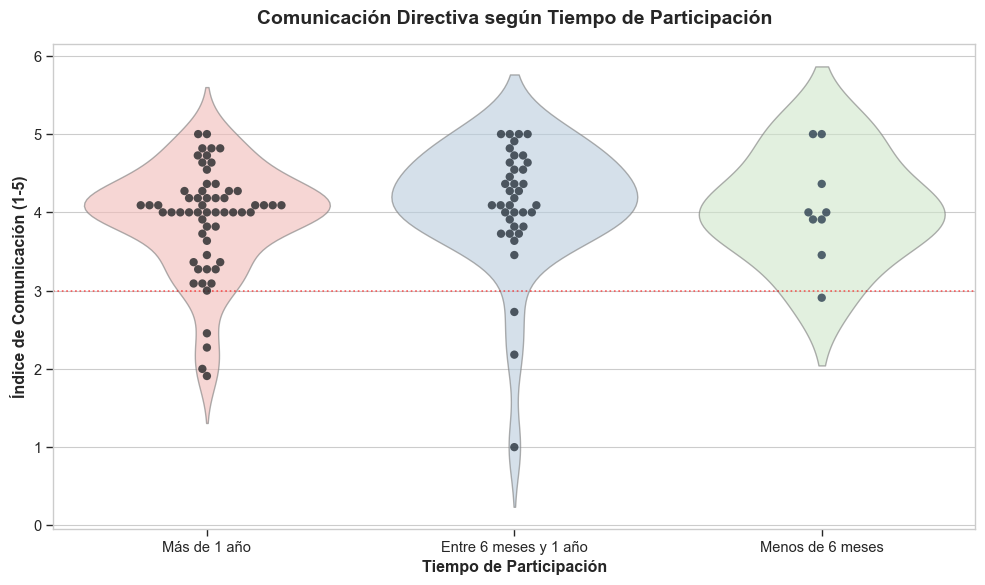

[+] Exportado exitosamente: graficos_tesis/05_heatmap_items_criticos


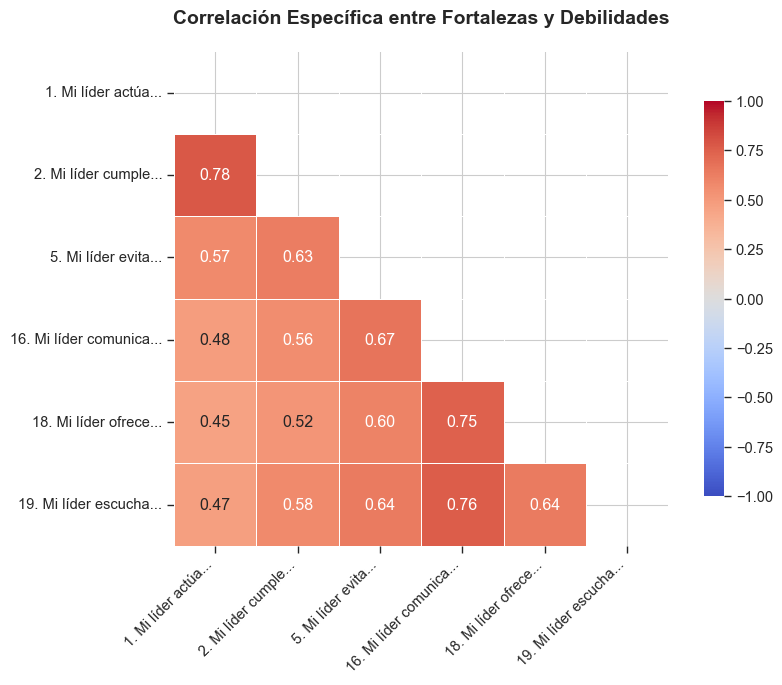

In [62]:
os.makedirs("graficos_tesis", exist_ok=True)

# Función para guardar automáticamente cada figura en Alta Calidad (PNG y PDF)
def guardar_fig(nombre_archivo):
    plt.tight_layout()
    # Guarda en PNG para presentaciones (PowerPoint, Word)
    plt.savefig(f"graficos_tesis/{nombre_archivo}.png", dpi=300, bbox_inches="tight")
    # Guarda en PDF para el documento de tesis (mantiene calidad vectorial)
    plt.savefig(f"graficos_tesis/{nombre_archivo}.pdf", bbox_inches="tight")
    print(f"[+] Exportado exitosamente: graficos_tesis/{nombre_archivo}")

# Estilo académico general
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Filtrar solo las preguntas tipo Likert
cols_likert = [col for col in df_clean.columns if re.match(r'^\d+\.', col)]


# ==========================================
# 1. GRÁFICO DE PIRULETA (FORTALEZAS Y DEBILIDADES)
# ==========================================
plt.figure(figsize=(10, 8))

# Calcular promedios y ordenar de menor a mayor
medias_items = df_clean[cols_likert].mean().sort_values(ascending=True)

# Acortar nombres para que quepan en el eje Y
nombres_cortos = [col.split('.')[0] + ". " + ' '.join(col.split('.')[1].split()[:5]) + "..." for col in medias_items.index]

# Colores: Verde (5 mejores), Rojo (5 peores), Gris (el resto)
colores = ['#e74c3c' if i < 5 else '#2ca02c' if i >= len(medias_items)-5 else '#95a5a6' for i in range(len(medias_items))]

plt.hlines(y=range(len(medias_items)), xmin=1, xmax=medias_items.values, color=colores, alpha=0.8, linewidth=3)
plt.scatter(medias_items.values, range(len(medias_items)), color=colores, s=100, zorder=3)

plt.title('Fortalezas y Puntos Críticos: Promedio por Pregunta', pad=20, weight='bold', fontsize=14)
plt.xlabel('Puntuación Promedio (Escala Likert 1-5)', weight='bold')
plt.xlim(1, 5)
plt.axvline(x=3, color='black', linestyle='--', alpha=0.5)

# Llamamos a la función para guardar y mostrar
guardar_fig("03_lollipop_fortalezas_debilidades")
plt.show()


# ==========================================
# 2. VIOLÍN + ANOVA (TIEMPO DE PARTICIPACIÓN VS COMUNICACIÓN)
# ==========================================
col_tiempo = 'Tiempo de participación en el proyecto'

# Ejecutar ANOVA estadístico
grupos_tiempo = [grupo['Indice_Comunicacion'].dropna().values for nombre, grupo in df_clean.groupby(col_tiempo) if len(grupo) > 0]
if len(grupos_tiempo) > 1:
    f_stat, p_anova = stats.f_oneway(*grupos_tiempo)
    print(f"\n--- ANOVA: TIEMPO DE PARTICIPACIÓN ---")
    print(f"Valor p: {p_anova:.3f}")

plt.figure(figsize=(10, 6))

sns.violinplot(
    x=col_tiempo, 
    y='Indice_Comunicacion', 
    data=df_clean, 
    palette='Pastel1',
    inner=None, 
    alpha=0.6,
    legend=False,
    hue=col_tiempo
)
sns.swarmplot(
    x=col_tiempo, 
    y='Indice_Comunicacion', 
    data=df_clean, 
    color='#2c3e50', 
    alpha=0.8, 
    size=6,
    legend=False,
    hue=col_tiempo
)

plt.title('Comunicación Directiva según Tiempo de Participación', pad=15, weight='bold', fontsize=14)
plt.ylabel('Índice de Comunicación (1-5)', weight='bold')
plt.xlabel('Tiempo de Participación', weight='bold')
plt.axhline(y=3, color='red', linestyle=':', alpha=0.6)

# Llamamos a la función para guardar y mostrar
guardar_fig("04_violin_anova_tiempo_comunicacion")
plt.show()


# ==========================================
# 3. HEATMAP DE CORRELACIÓN DE ÍTEMS CRÍTICOS
# ==========================================
plt.figure(figsize=(9, 7))

# Seleccionamos preguntas clave (Ajusta los números si varían en tu df_clean)
preg_claves = [
    [col for col in df_clean.columns if '1.' in col[:3]][0],  # Fortaleza
    [col for col in df_clean.columns if '2.' in col[:3]][0],  # Fortaleza
    [col for col in df_clean.columns if '5.' in col[:3]][0],  # Favoritismo
    [col for col in df_clean.columns if '16.' in col[:4]][0], # Tiempo/Oportunidad
    [col for col in df_clean.columns if '18.' in col[:4]][0], # Retroalimentación
    [col for col in df_clean.columns if '19.' in col[:4]][0]  # Escucha activa
]

df_heatmap = df_clean[preg_claves]
# Acortamos los nombres de las columnas para el gráfico
df_heatmap.columns = [col.split('.')[0] + ". " + ' '.join(col.split('.')[1].split()[:3]) + "..." for col in df_heatmap.columns]

corr_matrix = df_heatmap.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Oculta el triángulo superior repetido

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlación Específica entre Fortalezas y Debilidades', pad=20, weight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Llamamos a la función para guardar y mostrar
guardar_fig("05_heatmap_items_criticos")
plt.show()

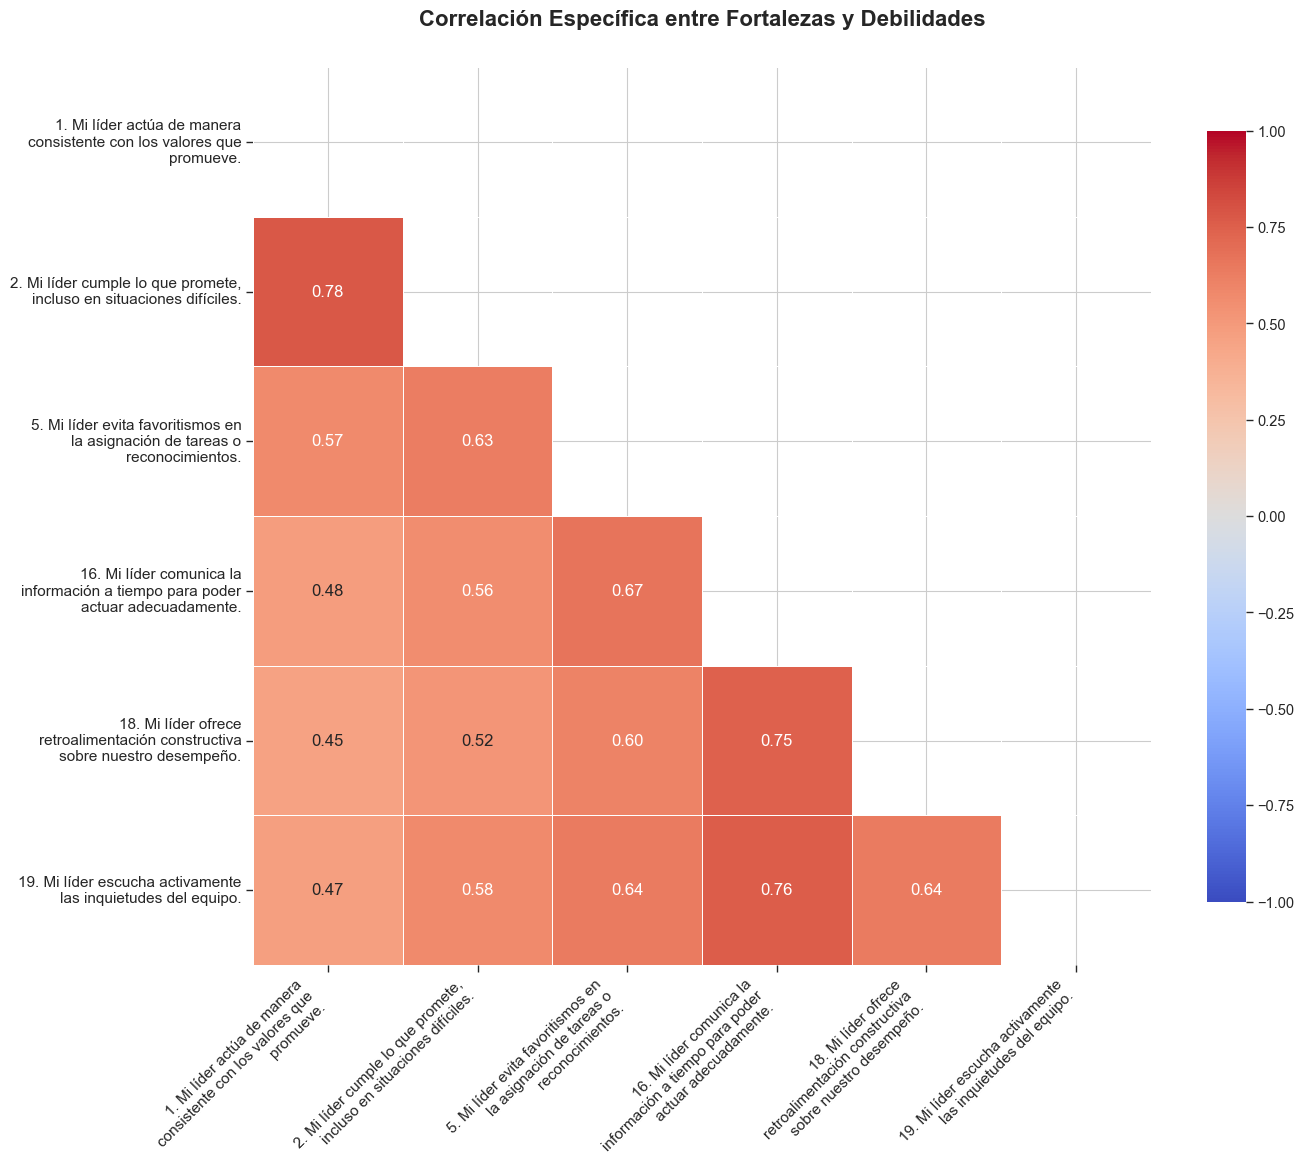

In [ ]:
# HEATMAP CON TEXTO COMPLETO Y MÚLTIPLES LÍNEAS
# ==========================================
# Aumentamos drásticamente el tamaño del lienzo para dar espacio al texto
plt.figure(figsize=(14, 12))

# 1. Volvemos a seleccionar las preguntas clave completas del dataframe original
preg_claves = [
    [col for col in df_clean.columns if '1.' in col[:3]][0],  
    [col for col in df_clean.columns if '2.' in col[:3]][0],  
    [col for col in df_clean.columns if '5.' in col[:3]][0],  
    [col for col in df_clean.columns if '16.' in col[:4]][0], 
    [col for col in df_clean.columns if '18.' in col[:4]][0], 
    [col for col in df_clean.columns if '19.' in col[:4]][0]  
]

df_heatmap = df_clean[preg_claves].copy()

# 2. El truco mágico: envolver el texto a un máximo de 35 caracteres por línea
nombres_envueltos = ['\n'.join(textwrap.wrap(col, width=35)) for col in df_heatmap.columns]
df_heatmap.columns = nombres_envueltos

# Calcular matriz y crear la máscara para el triángulo superior
corr_matrix = df_heatmap.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Dibujar el Heatmap con ajustes de tamaño
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,               # Muestra los números
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 12}    
)

plt.title('Correlación Específica entre Fortalezas y Debilidades', pad=30, weight='bold', fontsize=16)

# 4. Ajustar los ejes para que los textos largos no choquen
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Asegura que matplotlib calcule los márgenes sin cortar nada
plt.tight_layout()

# Opcional: Guardarlo en tu PC
plt.savefig("heatmap_preguntas_completas.png", dpi=300, bbox_inches="tight")

plt.show()